# SatQuery AI — FINAL Pipeline
### SIH PS 26167 (ISRO)

**This is the one notebook to use.** Start a brand-new Colab notebook, paste these cells
in, run top to bottom, in order, once. Do not mix this with any older notebook you've
been editing — that's what caused most of the errors so far (leftover dead-end cells
from earlier attempts colliding with newer fixes).

Runtime → Change runtime type → **GPU (T4)**, before running anything.

**What this notebook does, in order:**
1. Install everything, in the one order that actually works (verified in this
   conversation, not guessed)
2. Load BIFOLD's pretrained BEN-19 classifiers (S2 + S1+S2 fusion)
3. Build a real ConfigILM VQA model with the pretrained backbone grafted in
4. Upload your `BigEarthNet-VQA.parquet` and fetch **real** Sentinel imagery for each
   question via Google Earth Engine (not random noise — this was the critical bug in
   your previous training run)
5. Train on real (question, real image, answer) triples
6. Save the checkpoint + answer vocabulary for your Streamlit app
7. Change detection + Grad-CAM grounding + agentic controller (supporting tools)


## 1. Setup — run once, then restart

In [1]:
!pip install -q "fastcore<1.8"

!pip uninstall -y -q configilm
!pip install -q --ignore-requires-python "git+https://github.com/lhackel-tub/ConfigILM.git@v0.7.0"

!pip install -q bigearthnet_common bigearthnet_patch_interface lmdb psutil pytorch_lightning lightning
!pip install -q onnx onnxruntime grad-cam anthropic huggingface_hub safetensors rasterio earthengine-api

# grad-cam pulls numpy>=2, which breaks configilm==0.7.0 (needs numpy<2) — re-pin last
!pip install -q "numpy<2.0.0"

!git clone -q https://git.tu-berlin.de/rsim/reben-training-scripts.git
print("Setup complete.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastprogress 1.1.6 requires fastcore>=1.10.0, but you have fastcore 1.7.29 which is incompatible.
python-fasthtml 0.14.11 requires fastcore>=2.1.2, but you have fastcore 1.7.29 which is incompatible.
fastai 2.8.8 requires fastcore>=1.14.6, but you have fastcore 1.7.29 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 101.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.

### ⚠️ Restart the runtime now — required

`Runtime → Restart session` (NOT "Restart and run all"). This setup cell changes
numpy's version more than once; the already-running kernel has old compiled numpy
cached, so continuing without restarting causes a confusing crash a few cells later.
Everything is already installed on disk — nothing below needs the install cell again.


In [5]:
import torch, numpy as np
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cpu":
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU (T4).")

import configilm
print("configilm version:", configilm.__version__)
assert configilm.__version__.startswith("0.7"), "Wrong configilm version — re-run the setup cell."


Using device: cuda
configilm version: 0.7.0


## 2. Import `reben_publication` — self-healing (run once, after the restart)

In [6]:
import subprocess, sys, pathlib

repo_dir = pathlib.Path("/content/reben-training-scripts")
assert repo_dir.exists(), "Clone failed — re-run the setup cell and check its output for a git error."

installed = False
try:
    subprocess.run(["pip", "install", "-q", "--no-deps", str(repo_dir)], check=True)
    installed = True
    print("Installed reben_publication as a proper package.")
except subprocess.CalledProcessError:
    print("Package install failed — falling back to locating the file directly...")

if not installed:
    matches = list(repo_dir.rglob("BigEarthNetv2_0_ImageClassifier.py"))
    if not matches:
        raise RuntimeError(
            "Could not find BigEarthNetv2_0_ImageClassifier.py anywhere in the cloned repo. "
            "Run !find /content/reben-training-scripts -iname '*.py' and check the clone actually has content."
        )
    pkg_parent = matches[0].parent.parent
    sys.path.append(str(pkg_parent))
    print(f"Added {pkg_parent} to sys.path")

from reben_publication.BigEarthNetv2_0_ImageClassifier import BigEarthNetv2_0_ImageClassifier
print("Import successful.")


Package install failed — falling back to locating the file directly...
Added /content/reben-training-scripts to sys.path
Import successful.


## 3. BEN-19 classifiers (S2 + S1+S2 fusion) — used by change detection & grounding later

In [7]:
BEN19_CLASSES = [
    'Agro-forestry areas', 'Arable land', 'Beaches, dunes, sands', 'Broad-leaved forest',
    'Coastal wetlands', 'Complex cultivation patterns', 'Coniferous forest',
    'Industrial or commercial units', 'Inland waters', 'Inland wetlands',
    'Land principally occupied by agriculture, with significant areas of natural vegetation',
    'Marine waters', 'Mixed forest', 'Moors, heathland and sclerophyllous vegetation',
    'Natural grassland and sparsely vegetated areas', 'Pastures', 'Permanent crops',
    'Transitional woodland, shrub', 'Urban fabric'
]
S2_BANDS_V020 = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
S1_BANDS = ["VV", "VH"]

model_s2 = BigEarthNetv2_0_ImageClassifier.from_pretrained(
    "BIFOLD-BigEarthNetv2-0/resnet50-s2-v0.2.0"
).to(device).eval()

model_fusion = BigEarthNetv2_0_ImageClassifier.from_pretrained(
    "BIFOLD-BigEarthNetv2-0/resnet50-all-v0.2.0"
).to(device).eval()

print("Loaded S2 classifier:", sum(p.numel() for p in model_s2.parameters()), "params")
print("Loaded S1+S2 fusion classifier:", sum(p.numel() for p in model_fusion.parameters()), "params")


/usr/local/lib/python3.13/dist-packages/configilm/ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")


Loaded S2 classifier: 23568915 params
Loaded S1+S2 fusion classifier: 23575187 params


In [8]:
from configilm.extra.BENv2_utils import band_combi_to_mean_std

s2_mean, s2_std = band_combi_to_mean_std(10)
fusion_mean, fusion_std = band_combi_to_mean_std(12)
s2_mean, s2_std = np.array(s2_mean), np.array(s2_std)
fusion_mean, fusion_std = np.array(fusion_mean), np.array(fusion_std)

def load_s2_patch(band_arrays: dict) -> torch.Tensor:
    stacked = np.stack([band_arrays[b] for b in S2_BANDS_V020], axis=0).astype(np.float32)
    stacked = (stacked - s2_mean[:, None, None]) / s2_std[:, None, None]
    return torch.from_numpy(stacked).unsqueeze(0).float()

def load_fusion_patch(s1_bands: dict, s2_bands: dict) -> torch.Tensor:
    s1 = np.stack([s1_bands[b] for b in S1_BANDS], axis=0).astype(np.float32)
    s2 = np.stack([s2_bands[b] for b in S2_BANDS_V020], axis=0).astype(np.float32)
    stacked = np.concatenate([s1, s2], axis=0)
    stacked = (stacked - fusion_mean[:, None, None]) / fusion_std[:, None, None]
    return torch.from_numpy(stacked).unsqueeze(0).float()

@torch.no_grad()
def predict_s2(band_arrays: dict, threshold: float = 0.5):
    x = load_s2_patch(band_arrays).to(device)
    probs = torch.sigmoid(model_s2(x))[0].cpu().numpy()
    return sorted([(BEN19_CLASSES[i], float(probs[i])) for i in range(19) if probs[i] >= threshold],
                  key=lambda t: -t[1]), probs

print("Classifier helpers ready.")


Classifier helpers ready.


## 4. Build the VQA model + graft in the pretrained backbone

`network_type` is the enum `ILMType.VQA_CLASSIFICATION`. `image_size` is a plain int
with `channels` separate. The vision submodule is `vqa_model.vision_encoder` (confirmed
by inspecting the built model). `classes=` gets raised to your real answer vocabulary
size once you know it in Section 6 — 25 here is just a placeholder that gets rebuilt.


In [10]:
def smart_load_vision_weights(vision_encoder: torch.nn.Module, raw_state_dict: dict, verbose=True):
    """Auto-detects the checkpoint's key prefix and loads matching-shape tensors only,
    skipping the final classifier layer (shape differs from your answer vocabulary)."""
    target_sd = vision_encoder.state_dict()
    target_keys = set(target_sd.keys())
    candidate_prefixes = ["", "model.", "vision_encoder.", "model.vision_encoder.", "backbone."]
    best_prefix, best_hits = "", -1
    for p in candidate_prefixes:
        hits = sum(1 for k in raw_state_dict if k.startswith(p) and k[len(p):] in target_keys)
        if hits > best_hits:
            best_hits, best_prefix = hits, p
    if verbose:
        print(f"Detected checkpoint prefix: {best_prefix!r} ({best_hits}/{len(target_keys)} keys match)")
    to_load, skipped_shape = {}, []
    for k, v in raw_state_dict.items():
        if not k.startswith(best_prefix):
            continue
        stripped = k[len(best_prefix):]
        if stripped not in target_sd:
            continue
        if target_sd[stripped].shape != v.shape:
            skipped_shape.append((stripped, tuple(v.shape), tuple(target_sd[stripped].shape)))
            continue
        to_load[stripped] = v
    vision_encoder.load_state_dict(to_load, strict=False)
    if verbose:
        print(f"Loaded {len(to_load)}/{len(target_sd)} tensors into vision_encoder.")
        if skipped_shape:
            print("Skipped (shape mismatch — expected for the classifier head):")
            for name, src, tgt in skipped_shape:
                print(f"  {name}: checkpoint {src} vs model {tgt}")
    return to_load, skipped_shape


def build_vqa_model(num_classes: int):
    """Builds a fresh VQA model and grafts in the BIFOLD-pretrained backbone.
    Call this once you know your real answer vocabulary size (Section 6)."""
    from configilm.ConfigILM import ILMConfiguration, ConfigILM, ILMType
    from huggingface_hub import hf_hub_download
    import safetensors.torch

    cfg = ILMConfiguration(
        timm_model_name="resnet50",
        hf_model_name="prajjwal1/bert-tiny",
        classes=num_classes,
        channels=12,
        image_size=120,
        network_type=ILMType.VQA_CLASSIFICATION,
        load_pretrained_timm_if_available=False,
        load_pretrained_hf_if_available=True,
    )
    model = ConfigILM(cfg)
    model = model.to(device)

    weights_path = hf_hub_download(repo_id="BIFOLD-BigEarthNetv2-0/resnet50-all-v0.2.0", filename="model.safetensors")
    bifold_sd = safetensors.torch.load_file(weights_path)
    smart_load_vision_weights(model.vision_encoder, bifold_sd)
    return model

# Placeholder build so you can smoke-test the mechanism now — rebuilt for real in Section 6
vqa_model = build_vqa_model(num_classes=25)
print("Top-level submodules:")
for name, _ in vqa_model.named_children():
    print(" -", name)


/usr/local/lib/python3.13/dist-packages/configilm/ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")


AttributeError: 'NoneType' object has no attribute 'vision_encoder'

In [13]:
import torch


def smart_load_vision_weights(vision_encoder: torch.nn.Module, raw_state_dict: dict, verbose=True):
    """Auto-detects the checkpoint's key prefix and loads matching-shape tensors only,
    skipping the final classifier layer (shape differs from your answer vocabulary).
    """
    target_sd = vision_encoder.state_dict()
    target_keys = set(target_sd.keys())
    candidate_prefixes = ["", "model.", "vision_encoder.", "model.vision_encoder.", "backbone."]
    best_prefix, best_hits = "", -1
    for p in candidate_prefixes:
        hits = sum(1 for k in raw_state_dict if k.startswith(p) and k[len(p) :] in target_keys)
        if hits > best_hits:
            best_hits, best_prefix = hits, p
    if verbose:
        print(f"Detected checkpoint prefix: {best_prefix!r} ({best_hits}/{len(target_keys)} keys match)")
    to_load, skipped_shape = {}, []
    for k, v in raw_state_dict.items():
        if not k.startswith(best_prefix):
            continue
        stripped = k[len(best_prefix) :]
        if stripped not in target_sd:
            continue
        if target_sd[stripped].shape != v.shape:
            skipped_shape.append((stripped, tuple(v.shape), tuple(target_sd[stripped].shape)))
            continue
        to_load[stripped] = v
    vision_encoder.load_state_dict(to_load, strict=False)
    if verbose:
        print(f"Loaded {len(to_load)}/{len(target_sd)} tensors into vision_encoder.")
        if skipped_shape:
            print("Skipped (shape mismatch — expected for the classifier head):")
            for name, src, tgt in skipped_shape:
                print(f"  {name}: checkpoint {src} vs model {tgt}")
    return to_load, skipped_shape


def build_vqa_model(num_classes: int):
    """Builds a fresh VQA model and grafts in the BIFOLD-pretrained backbone."""
    from configilm.ConfigILM import ConfigILM, ILMConfiguration, ILMType
    from huggingface_hub import hf_hub_download
    import safetensors.torch

    cfg = ILMConfiguration(
        timm_model_name="resnet50",
        hf_model_name="prajjwal1/bert-tiny",
        classes=num_classes,
        channels=12,
        image_size=120,
        network_type=ILMType.VQA_CLASSIFICATION,
        load_pretrained_timm_if_available=False,
        load_pretrained_hf_if_available=True,
    )
    model = ConfigILM(cfg)

    # Safely retrieve vision_encoder whether nested under .model or directly on model
    vision_encoder = getattr(model, "vision_encoder", None)
    if vision_encoder is None and hasattr(model, "model"):
        vision_encoder = getattr(model.model, "vision_encoder", None)

    if vision_encoder is None:
        raise AttributeError("Could not locate `vision_encoder` attribute on the ConfigILM instance.")

    weights_path = hf_hub_download(
        repo_id="BIFOLD-BigEarthNetv2-0/resnet50-all-v0.2.0", filename="model.safetensors"
    )
    bifold_sd = safetensors.torch.load_file(weights_path)

    smart_load_vision_weights(vision_encoder, bifold_sd)

    # Move to device in-place WITHOUT reassignment
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    return model


# Placeholder build so you can smoke-test the mechanism now
vqa_model = build_vqa_model(num_classes=25)
print("\nTop-level submodules:")
for name, _ in vqa_model.named_children():
    print(" -", name)

Detected checkpoint prefix: 'model.vision_encoder.' (320/320 keys match)
Loaded 318/320 tensors into vision_encoder.
Skipped (shape mismatch — expected for the classifier head):
  fc.bias: checkpoint (19,) vs model (512,)
  fc.weight: checkpoint (19, 2048) vs model (512, 2048)

Top-level submodules:
 - vision_encoder
 - text_encoder
 - text_linear
 - visual_linear
 - dropout_v
 - dropout_q
 - fusion


In [14]:
# Forward-pass smoke test — confirms the architecture works before real data
dummy_img = torch.rand(2, 12, 120, 120).to(device)
dummy_question_ids = torch.randint(0, 30000, (2, 32)).to(device)
vqa_model.eval()
with torch.no_grad():
    logits = vqa_model((dummy_img, dummy_question_ids))
print("VQA model output shape:", logits.shape, "-> [batch, classes]  (mechanism confirmed working)")


VQA model output shape: torch.Size([2, 25]) -> [batch, classes]  (mechanism confirmed working)


## 5. Upload your parquet + fetch REAL imagery via Earth Engine

**This replaces the critical bug from your previous run**, where every training image
was `torch.rand(...)` — random noise. The model wasn't learning to see; it was learning
a text-only shortcut, which is why the loss dropped to near-zero in one epoch.

Your parquet already has `latitude`/`longitude`/`season` per row — that's enough to
pull the real Sentinel-1/Sentinel-2 imagery directly, without downloading BigEarthNet's
~110GB archive.


In [17]:
# from google.colab import files
# print("Upload BigEarthNet-VQA.parquet:")
# uploaded = files.upload()


In [25]:
import pandas as pd

df = pd.read_parquet("/content/BigEarthNet-VQA.parquet")
print("Columns:", df.columns.tolist())
print("Total rows:", len(df))

q_col, a_col = "input", "output"
if "split" in df.columns:
    df = df[df["split"] == "train"].copy()
if "type" in df.columns:
    df = df[df["type"] != "caption"].copy()

# MODIFIED LINE: Randomly sample exactly 2,000 unique patches
unique_patches = df[["patch_id", "latitude", "longitude", "season"]].drop_duplicates("patch_id").sample(n=2000, random_state=42)

print(f"{len(df)} usable QA rows across {len(unique_patches)} unique patches "
      f"(~{len(unique_patches) * 675 / 1024:.1f} MB once cached)")

Columns: ['ID', 's1_name', 'patch_id', 'input', 'output', 'type', 'category', 'split', 'latitude', 'longitude', 'country', 'season', 'climate_zone']
Total rows: 9553962
4674281 usable QA rows across 2000 unique patches (~1318.4 MB once cached)


In [26]:
import ee

ee.Authenticate() # one-time interactive login

# Using the Project ID from your Google Cloud Console
ee.Initialize(project="gen-lang-client-0849351832")

print("Earth Engine ready.")

Earth Engine ready.


In [33]:
import cv2
import ee
import numpy as np

# Define Earth Engine compatible band lists
S1_BANDS = ["VV", "VH"]
S2_BANDS_GEE = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"]

def fetch_real_patch(lat: float, lon: float, season: str, patch_size_m: int = 1200, target_size: int = 120):
    """Pulls real Sentinel-1 + Sentinel-2 bands for a coordinate and resizes all bands to target_size x target_size."""
    point = ee.Geometry.Point([lon, lat])
    region = point.buffer(patch_size_m / 2).bounds()

    season_months = {"Winter": (12, 2), "Spring": (3, 5), "Summer": (6, 8), "Autumn": (9, 11), "Fall": (9, 11)}
    start_month, end_month = season_months.get(season, (6, 8))

    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterBounds(region)
          .filter(ee.Filter.calendarRange(start_month, end_month, "month"))
          .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
          .sort("CLOUDY_PIXEL_PERCENTAGE")
          .first())
    s1 = (ee.ImageCollection("COPERNICUS/S1_GRD")
          .filterBounds(region)
          .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
          .filter(ee.Filter.eq("instrumentMode", "IW"))
          .first())

    bands = {}
    try:
        s2_sample = s2.select(S2_BANDS_GEE).sampleRectangle(region=region, defaultValue=0).getInfo()
        for b in S2_BANDS_GEE:
            arr = np.array(s2_sample["properties"][b], dtype=np.float32)
            # Ensure every band is resized to (120, 120)
            if arr.shape != (target_size, target_size):
                arr = cv2.resize(arr, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
            bands[b] = arr

        s1_sample = s1.select(S1_BANDS).sampleRectangle(region=region, defaultValue=0).getInfo()
        for b in S1_BANDS:
            arr = np.array(s1_sample["properties"][b], dtype=np.float32)
            if arr.shape != (target_size, target_size):
                arr = cv2.resize(arr, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
            bands[b] = arr
    except Exception as e:
        print(f"Skipping ({lat},{lon}): {e}")
        return None
    return bands

Testing: lat=47.77890546193844, lon=12.93090874926039, season=Summer
B1: shape=(120, 120), range=[107.2, 999.2]
B2: shape=(120, 120), range=[69.2, 2876.1]
B3: shape=(120, 120), range=[190.0, 3125.6]
B4: shape=(120, 120), range=[141.4, 4284.6]
B5: shape=(120, 120), range=[418.7, 3759.9]
B6: shape=(120, 120), range=[333.3, 4416.6]
B7: shape=(120, 120), range=[361.8, 5337.6]
B8: shape=(120, 120), range=[405.5, 6091.4]
B8A: shape=(120, 120), range=[419.4, 5468.2]
B9: shape=(120, 120), range=[1105.4, 4872.6]
B11: shape=(120, 120), range=[318.7, 6100.1]
B12: shape=(120, 120), range=[174.3, 5698.1]
VV: shape=(120, 120), range=[-21.9, 0.9]
VH: shape=(120, 120), range=[-28.7, -4.4]


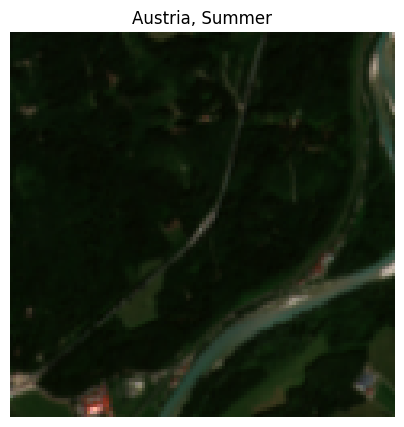

Looks right? If yes, proceed to the full fetch loop below.


In [34]:
# --- Validate on ONE patch before committing to the full loop ---
import matplotlib.pyplot as plt

test_row = df.iloc[0]
print(f"Testing: lat={test_row['latitude']}, lon={test_row['longitude']}, season={test_row['season']}")
test_bands = fetch_real_patch(test_row['latitude'], test_row['longitude'], test_row['season'])

if test_bands is None:
    print("FAILED — try a different row, or widen the cloud-cover filter, before running the full loop.")
else:
    for b, arr in test_bands.items():
        print(f"{b}: shape={arr.shape}, range=[{arr.min():.1f}, {arr.max():.1f}]")
    rgb = np.stack([test_bands["B4"], test_bands["B3"], test_bands["B2"]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    plt.figure(figsize=(5, 5)); plt.imshow(rgb); plt.axis("off")
    plt.title(f"{test_row['country']}, {test_row['season']}"); plt.show()
    print("Looks right? If yes, proceed to the full fetch loop below.")

In [35]:
import os
import pickle

CACHE_PATH = "/content/patch_image_cache.pkl"
patch_cache = pickle.load(open(CACHE_PATH, "rb")) if os.path.exists(CACHE_PATH) else {}

print(f"{len(unique_patches)} unique patches to fetch ({len(patch_cache)} already cached).")

for i, row in unique_patches.iterrows():
    pid = row["patch_id"]
    if pid in patch_cache:
        continue
    bands = fetch_real_patch(row["latitude"], row["longitude"], row["season"])
    if bands is not None:
        stacked = np.stack([bands[b] for b in (S1_BANDS + S2_BANDS_GEE)], axis=0)
        patch_cache[pid] = stacked
    if len(patch_cache) > 0 and len(patch_cache) % 100 == 0:
        pickle.dump(patch_cache, open(CACHE_PATH, "wb"))
        print(f"Checkpointed at {len(patch_cache)} patches...")

pickle.dump(patch_cache, open(CACHE_PATH, "wb"))
print(f"Done. Cached {len(patch_cache)}/{len(unique_patches)} real patches.")

2000 unique patches to fetch (0 already cached).
Checkpointed at 100 patches...
Checkpointed at 200 patches...
Checkpointed at 300 patches...


Checkpointed at 400 patches...
Checkpointed at 500 patches...
Checkpointed at 600 patches...
Checkpointed at 700 patches...
Checkpointed at 800 patches...
Checkpointed at 900 patches...
Checkpointed at 1000 patches...
Checkpointed at 1100 patches...
Checkpointed at 1200 patches...


Checkpointed at 1300 patches...
Checkpointed at 1400 patches...
Checkpointed at 1500 patches...
Checkpointed at 1600 patches...
Checkpointed at 1700 patches...
Checkpointed at 1800 patches...
Checkpointed at 1900 patches...
Checkpointed at 2000 patches...
Done. Cached 2000/2000 real patches.


## 6. Train on real (question, real image, answer) triples

In [38]:
from torch.utils.data import Dataset, DataLoader
from configilm.util import get_default_tokenizer

tokenizer = get_default_tokenizer()

# Restrict to top-N frequent answers and rows whose patch actually got cached
answer_counts = df[a_col].value_counts()
top_answers = answer_counts.head(1000).index.tolist()
df_train = df[df[a_col].isin(top_answers)].copy()
df_train[a_col] = df_train[a_col].astype(str)
df_train = df_train[df_train["patch_id"].isin(patch_cache.keys())].reset_index(drop=True)

unique_answers = sorted(df_train[a_col].unique().tolist())
answer_to_id = {ans: i for i, ans in enumerate(unique_answers)}

print(f"Training rows with a real cached image: {len(df_train)}")
print(f"Answer vocabulary size: {len(answer_to_id)}")


class ParquetVQADataset(Dataset):
    def __init__(self, dataframe, ans_to_id, tokenizer, patch_cache, q_key, a_key, max_seq_len=32):
        self.df = dataframe.reset_index(drop=True)
        self.ans_to_id, self.tokenizer, self.patch_cache = ans_to_id, tokenizer, patch_cache
        self.q_key, self.a_key, self.max_seq_len = q_key, a_key, max_seq_len
        # Band indices to map 14 cached bands (2 S1 + 12 S2) down to the 12 BIFOLD channels (2 S1 + 10 standard S2, skipping B1 & B9)
        self.bifold_12_idx = [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        q_ids = self.tokenizer.encode(str(row[self.q_key]), max_length=self.max_seq_len,
                                       padding="max_length", truncation=True)
        ans_tensor = torch.zeros(len(self.ans_to_id), dtype=torch.float)
        ans_tensor[self.ans_to_id[str(row[self.a_key])]] = 1.0

        img = self.patch_cache[row["patch_id"]]  # REAL image

        # Slice 14 channels down to 12 matching BIFOLD expected input
        if img.shape[0] == 14:
            img = img[self.bifold_12_idx]

        # Apply mean/std normalization
        img = (img - fusion_mean[:, None, None]) / fusion_std[:, None, None]
        return torch.from_numpy(img).float(), torch.tensor(q_ids, dtype=torch.long), ans_tensor


def collate(batch):
    imgs = torch.stack([b[0] for b in batch])
    qs = torch.stack([b[1] for b in batch])
    ans = torch.stack([b[2] for b in batch])
    return imgs, qs, ans


train_ds = ParquetVQADataset(df_train, answer_to_id, tokenizer, patch_cache, q_col, a_col)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate)
print(f"Dataset ready: {len(train_ds)} real training examples.")

Training rows with a real cached image: 31689
Answer vocabulary size: 579
Dataset ready: 31689 real training examples.


In [39]:
import torch.nn as nn

# Rebuild the VQA model now that we know the REAL vocabulary size
vqa_model = build_vqa_model(num_classes=len(answer_to_id))

optimizer = torch.optim.AdamW(vqa_model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 5
vqa_model.train()

for epoch in range(EPOCHS):
    running_loss = 0.0
    for imgs, qs, ans in train_loader:
        imgs, qs, ans = imgs.to(device), qs.to(device), ans.to(device)
        optimizer.zero_grad()
        logits = vqa_model((imgs, qs))
        loss = criterion(logits, ans)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    print(f"epoch {epoch+1}/{EPOCHS} — loss {running_loss/len(train_ds):.4f}")

vqa_model.eval()

print("\nTraining complete! Proceed to Section 7 to save your model.")

/usr/local/lib/python3.13/dist-packages/configilm/ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")
/usr/local/lib/python3.13/dist-packages/configilm/ConfigILM.py:108: UserWarning: Tokenizer was initialized pretrained
  warnings.warn("Tokenizer was initialized pretrained")


Detected checkpoint prefix: 'model.vision_encoder.' (320/320 keys match)
Loaded 318/320 tensors into vision_encoder.
Skipped (shape mismatch — expected for the classifier head):
  fc.bias: checkpoint (19,) vs model (512,)
  fc.weight: checkpoint (19, 2048) vs model (512, 2048)
epoch 1/5 — loss 0.1667
epoch 2/5 — loss 0.0209
epoch 3/5 — loss 0.0111
epoch 4/5 — loss 0.0081
epoch 5/5 — loss 0.0068

Training complete! Proceed to Section 7 to save your model.


In [41]:
import json

torch.save(vqa_model.state_dict(), "/content/satquery_vqa_finetuned.pt")
json.dump(answer_to_id, open("/content/answer_vocab.json", "w"))
print("Saved checkpoint + vocabulary. Download both files and drop them into your satquery_app folder:")
print(" - /content/satquery_vqa_finetuned.pt")
print(" - /content/answer_vocab.json")

from google.colab import files
files.download("/content/satquery_vqa_finetuned.pt")
files.download("/content/answer_vocab.json")


Saved checkpoint + vocabulary. Download both files and drop them into your satquery_app folder:
 - /content/satquery_vqa_finetuned.pt
 - /content/answer_vocab.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Change detection + Grad-CAM grounding (supporting tools)

In [42]:
def change_detection(bands_t1: dict, bands_t2: dict, threshold: float = 0.5):
    preds_t1, _ = predict_s2(bands_t1, threshold)
    preds_t2, _ = predict_s2(bands_t2, threshold)
    classes_t1 = {c for c, _ in preds_t1}
    classes_t2 = {c for c, _ in preds_t2}
    appeared = sorted(classes_t2 - classes_t1)
    disappeared = sorted(classes_t1 - classes_t2)
    return {"t1_classes": sorted(classes_t1), "t2_classes": sorted(classes_t2),
            "appeared": appeared, "disappeared": disappeared,
            "unchanged": sorted(classes_t1 & classes_t2), "has_change": bool(appeared or disappeared)}

print("change_detection ready.")


change_detection ready.


In [43]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def ground_class(band_arrays: dict, class_name: str):
    class_idx = BEN19_CLASSES.index(class_name)
    x = load_s2_patch(band_arrays).to(device)
    target_layers = [model_s2.model.layer4[-1]] if hasattr(model_s2, "model") else [model_s2.layer4[-1]]
    cam = GradCAM(model=model_s2, target_layers=target_layers)
    return cam(input_tensor=x, targets=[ClassifierOutputTarget(class_idx)])[0]

print("ground_class ready.")


ground_class ready.


## Next steps

- Drop `satquery_vqa_finetuned.pt` + `answer_vocab.json` next to your `app.py` and
  relaunch the Streamlit app — it should now show real decoded answers with confidence.
- If the fetch loop is slow, it's proportional to unique patches, not total QA rows —
  check the printed count in Section 5 before committing to the full run.
- Evaluate against VRSBench/RSVQA (single-image) and CDVQA (change) test splits per
  the PS's judging criteria, once real-image training looks healthy.
